![CNN Architecture](images/cover.png)

# **LIBRARY**

In [2]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [3]:
SEED = 1082
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# **DATA**

In [4]:
KAGGLE_PATH = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Reusable function: scan folder per-kelas dan kembalikan dataframe path + label
def build_image_dataframe(root_dir):
    image_paths = []
    image_labels = []

    class_dirs = sorted(os.listdir(root_dir))
    for class_name in class_dirs:
        class_path = os.path.join(root_dir, class_name)
        for file_name in os.listdir(class_path):
            image_paths.append(os.path.join(class_path, file_name))
            image_labels.append(class_name)

    paths_series = pd.Series(image_paths, name="image_path")
    labels_series = pd.Series(image_labels, name="image_label")
    return pd.concat([paths_series, labels_series], axis=1)


df_train = build_image_dataframe(os.path.join(KAGGLE_PATH, "Training"))
df_test_full = build_image_dataframe(os.path.join(KAGGLE_PATH, "Testing"))

print("Training set shape:", df_train.shape)
print("Testing (full) set shape:", df_test_full.shape)
df_train.head()

Training set shape: (5600, 2)
Testing (full) set shape: (1600, 2)


,image_path,image_label
0,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma
1,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma
2,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma
3,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma
4,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma


# **SPLIT VALIDATION & TEST**

In [5]:
df_valid, df_test = train_test_split(
    df_test_full,
    test_size=0.5,
    stratify=df_test_full["image_label"],
    shuffle=True,
    random_state=SEED
)

print("Validation set shape:", df_valid.shape)
print("Final test set shape:", df_test.shape)

print("\nDistribusi kelas di df_valid:")
print(df_valid["image_label"].value_counts())

print("\nDistribusi kelas di df_test:")
print(df_test["image_label"].value_counts())

Validation set shape: (800, 2)
Final test set shape: (800, 2)

Distribusi kelas di df_valid:
image_label
glioma        200
pituitary     200
meningioma    200
notumor       200
Name: count, dtype: int64

Distribusi kelas di df_test:
image_label
meningioma    200
glioma        200
notumor       200
pituitary     200
Name: count, dtype: int64


# **PRE-PROCESSING DATA**

Pre-Processing yang dilakukan meliputi:
- Resize gambar ke pixel yang sama, yakni [224 x 224]
- Normalisasi nilai pixel ke rentang [0, 1] (rescale 1./255)
- **Augmentasi data** pada train set (rotation, zoom, horizontal flip, brightness) untuk memperkaya variasi data dan mengurangi overfitting
- Label di-encode otomatis menjadi one-hot (`class_mode='categorical'`)

Augmentasi hanya diterapkan pada train set. Validation dan test set hanya di-rescale (tanpa augmentasi) agar evaluasi tetap representatif terhadap data asli.

In [6]:
# Generator untuk training: rescale + augmentasi ringan
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=(0.9, 1.1)
)

# Generator untuk validation/test: rescale saja (tanpa augmentasi, demi evaluasi yang adil)
eval_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_dataframe(
    df_train,
    x_col='image_path',
    y_col='image_label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_data = eval_gen.flow_from_dataframe(
    df_valid,
    x_col='image_path',
    y_col='image_label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_data = eval_gen.flow_from_dataframe(
    df_test,
    x_col='image_path',
    y_col='image_label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Mapping index kelas -> nama kelas (dipakai di seluruh notebook)
class_indices = train_data.class_indices
CLASSES = list(class_indices.keys())
print("Class indices:", class_indices)
print("CLASSES:", CLASSES)

Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
CLASSES: ['glioma', 'meningioma', 'notumor', 'pituitary']


# **EKSPLORASI DATA**

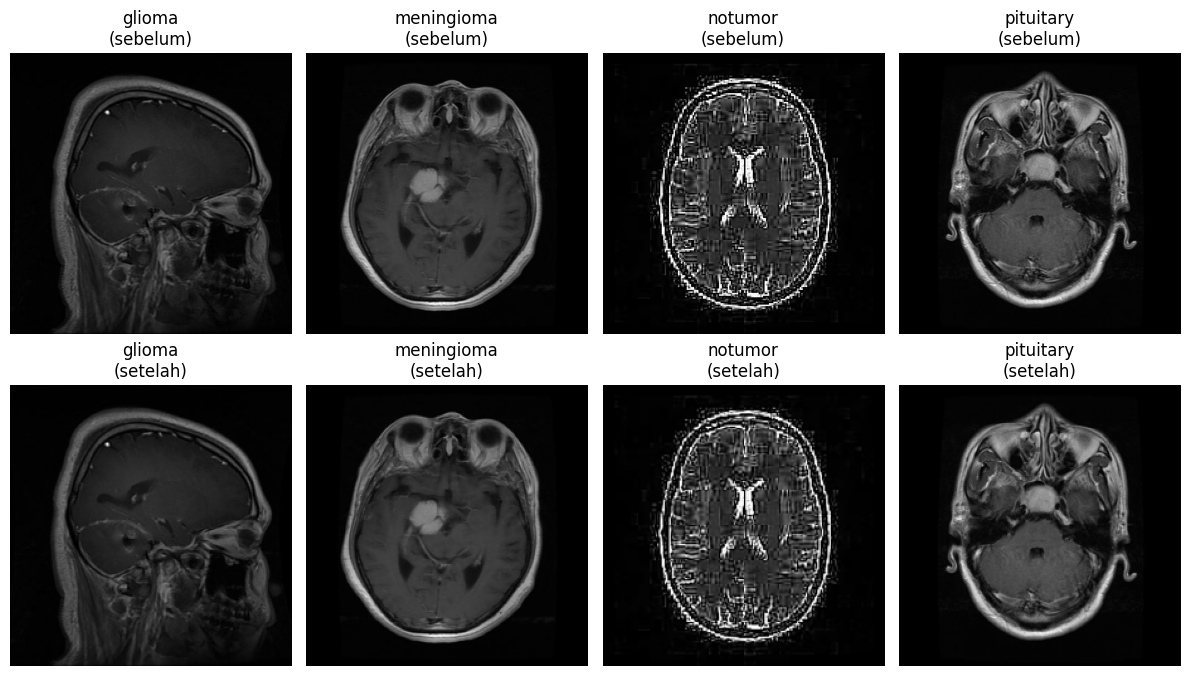

In [7]:
from PIL import Image

# Ambil 1 path gambar mentah per kelas dari df_train
sample_paths_raw = {}
for cls in CLASSES:
    path = df_train[df_train['image_label'] == cls]['image_path'].iloc[0]
    sample_paths_raw[cls] = path

fig, axes = plt.subplots(2, len(CLASSES), figsize=(12, 7))

for idx, class_name in enumerate(CLASSES):
    # Gambar sebelum pre-processing (langsung dari file, resolusi asli)
    raw_img = Image.open(sample_paths_raw[class_name]).convert("RGB")
    raw_array = np.array(raw_img)
    resized_img = raw_img.resize(IMG_SIZE)
    processed_array = eval_gen.standardize(np.array(resized_img).astype("float32"))

    axes[0, idx].imshow(raw_array)
    axes[0, idx].set_title(f"{class_name}\n(sebelum)")
    axes[0, idx].axis('off')

    axes[1, idx].imshow(processed_array)
    axes[1, idx].set_title(f"{class_name}\n(setelah)")
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

In [8]:
# Cek rentang nilai pixel sebelum dan sesudah pre-processing
print("Sebelum:", raw_array.min(), raw_array.max())
print("Setelah:", processed_array.min(), processed_array.max())

Sebelum: 0 255
Setelah: 0.0 0.9607844


Kalau untuk pre-process di data train, val, dan test secara bersamaan hanya dilakukan rescale gambar saja. Makanya perubahan Before-Afternya tidak terlalu terlihat. Namun, pre-processing lanjutan untuk data trainnya baru terlihat di bawah ini, yakni augmentasi data. Hal ini dilakukan untuk mencegah terjadinya overfitting selama proses pelatihan model (model terlalu menghafal gambar di data latih)

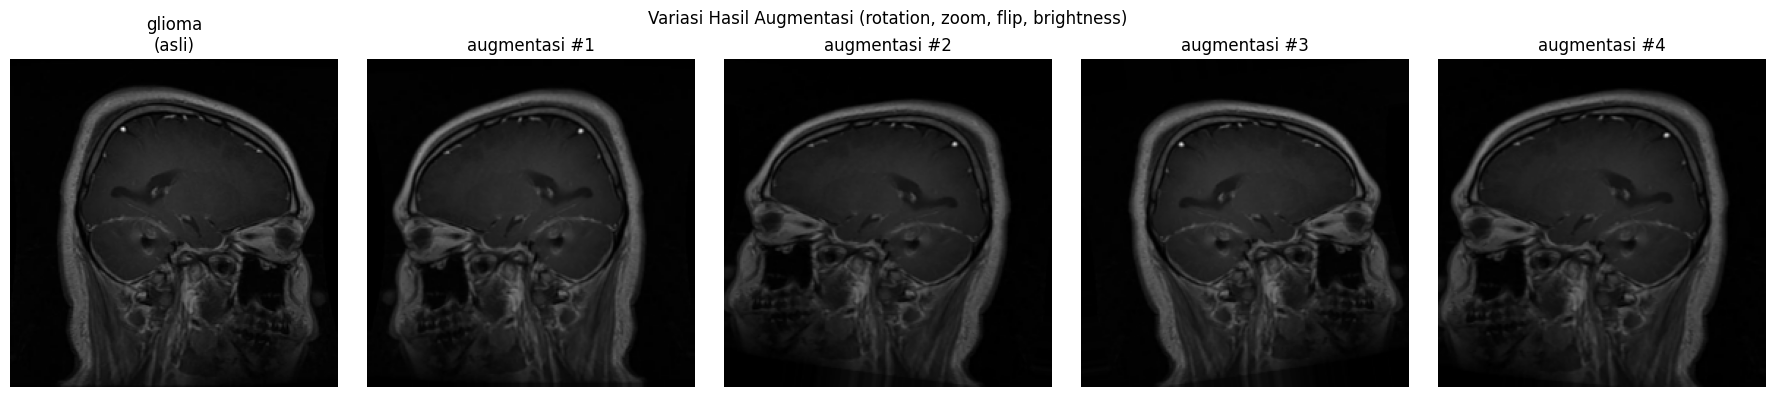

In [9]:
# Contoh hasil augmentasi pada 1 gambar yang sama (diulang beberapa kali)
sample_path = df_train['image_path'].iloc[0]
sample_class = df_train['image_label'].iloc[0]

raw_img = Image.open(sample_path).convert("RGB").resize(IMG_SIZE)
raw_array = np.array(raw_img).astype("float32")

n_augmented = 4
fig, axes = plt.subplots(1, n_augmented + 1, figsize=(18, 4))

# Gambar asli (setelah resize, sebelum augmentasi)
axes[0].imshow(raw_array / 255.0)
axes[0].set_title(f"{sample_class}\n(asli)")
axes[0].axis('off')

# Beberapa hasil augmentasi acak dari train_gen
for i in range(n_augmented):
    augmented = train_gen.random_transform(raw_array.copy())
    augmented = train_gen.standardize(augmented)  # terapkan rescale 1./255

    axes[i + 1].imshow(np.clip(augmented, 0, 1))
    axes[i + 1].set_title(f"augmentasi #{i+1}")
    axes[i + 1].axis('off')

plt.suptitle("Variasi Hasil Augmentasi (rotation, zoom, flip, brightness)")
plt.tight_layout()
plt.show()

# **CNN**

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D, Conv2D, BatchNormalization, MaxPooling2D
from tensorflow.keras.optimizers import Adam
custom_cnn = Sequential([
    # Block 1
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.20),

    # Block 2
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.30),

    # Block 4
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.35),

    # Classification head
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(len(CLASSES), activation='softmax')
], name="custom_cnn")

# Compile the model
custom_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

custom_cnn.summary()

I0000 00:00:1782048844.648456      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782048844.654401      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,243,940 (4.75 MB)

 Trainable params: 1,241,508 (4.74 MB)

 Non-trainable params: 2,432 (9.50 KB)

## **Training Model**

In [11]:
import time
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

start_time = time.time()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

history = custom_cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=100,
    callbacks=[early_stop, reduce_lr]
)

end_time = time.time()
elapsed = end_time - start_time

hours, rem = divmod(elapsed, 3600)
minutes, seconds = divmod(rem, 60)
print(f"\nTotal waktu training: {int(hours)} jam {int(minutes)} menit {seconds:.4f} detik")

Epoch 1/100


I0000 00:00:1782048864.714136     138 service.cc:152] XLA service 0x7dc27810ea60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782048864.714191     138 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782048864.714197     138 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782048865.890450     138 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782048886.779551     138 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


175/175 ━━━━━━━━━━━━━━━━━━━━ 130s 583ms/step - accuracy: 0.6007 - loss: 1.1122 - val_accuracy: 0.2500 - val_loss: 2.6066 - learning_rate: 0.0010
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 77s 440ms/step - accuracy: 0.7365 - loss: 0.7297 - val_accuracy: 0.2387 - val_loss: 3.8867 - learning_rate: 0.0010
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 77s 440ms/step - accuracy: 0.7849 - loss: 0.5919 - val_accuracy: 0.2500 - val_loss: 7.2311 - learning_rate: 0.0010
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 77s 439ms/step - accuracy: 0.8185 - loss: 0.4790 - val_accuracy: 0.6888 - val_loss: 1.0507 - learning_rate: 0.0010
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 77s 439ms/step - accuracy: 0.8433 - loss: 0.4273 - val_accuracy: 0.4363 - val_loss: 2.6140 - learning_rate: 0.0010
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 77s 441ms/step - accuracy: 0.8446 - loss: 0.4386 - val_accuracy: 0.6425 - val_loss: 1.1148 - learning_rate: 0.0010
Epoch 7/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 77s 437ms/step - accuracy: 0.8496 

## **Evaluasi Model**

Model      | Train Acc (%)   | Val Acc (%)     | Test Acc (%)   
----------------------------------------------------------------------
CNN        | 96.0893         | 91.6250         | 93.1250        


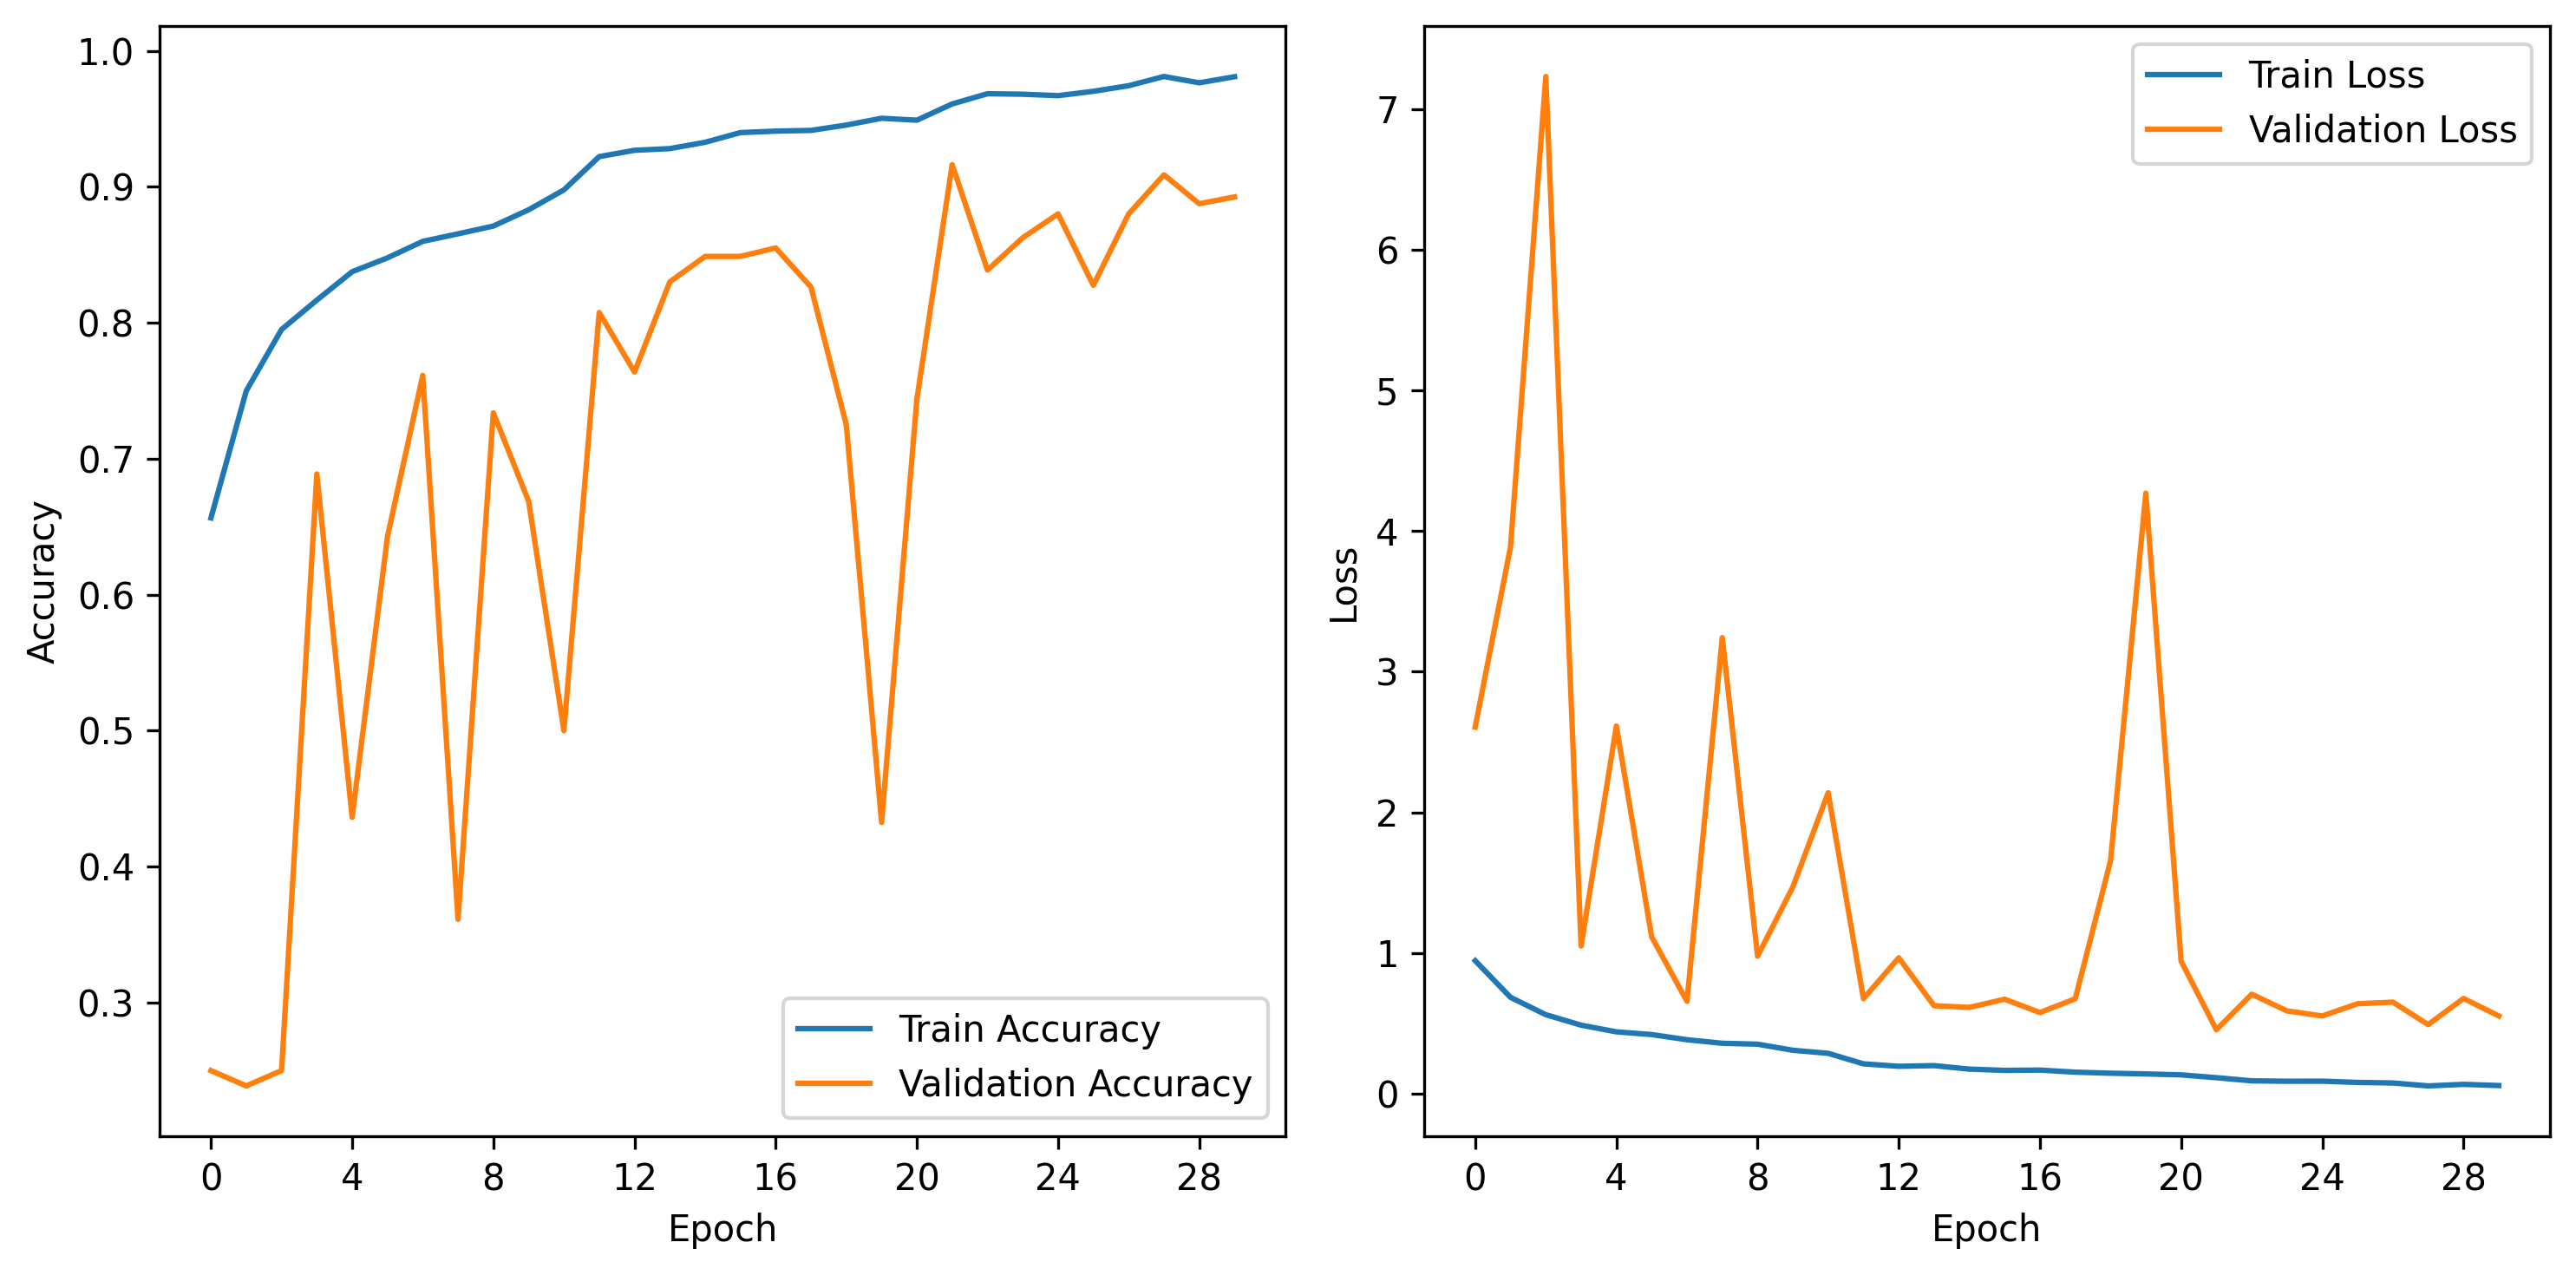

In [19]:
from matplotlib.ticker import MaxNLocator

test_data.reset()
test_loss, test_acc = custom_cnn.evaluate(test_data, verbose=0)
best_epoch = np.argmin(history.history['val_loss'])
train_acc = history.history['accuracy'][best_epoch]
train_loss = history.history['loss'][best_epoch]
val_acc = history.history['val_accuracy'][best_epoch]
val_loss = history.history['val_loss'][best_epoch]

print(f"{'Model':<10} | {'Train Acc (%)':<15} | {'Val Acc (%)':<15} | {'Test Acc (%)':<15}")
print("-" * 70)
print(f"{'CNN':<10} | {train_acc*100:<15.4f} | {val_acc*100:<15.4f} | {test_acc*100:<15.4f}")

fig = plt.figure(figsize=(10, 5), dpi=300)  # 2 subplot @ 5x5 inch berdampingan

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.legend()

plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=300, bbox_inches=None)
plt.show()

In [14]:
test_data.reset()
y_pred_prob = custom_cnn.predict(test_data, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_data.classes  # label asli sesuai urutan generator (shuffle=False)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))


Classification Report:
              precision    recall  f1-score   support

      glioma     0.9873    0.7750    0.8683       200
  meningioma     0.8590    0.9750    0.9133       200
     notumor     0.9174    1.0000    0.9569       200
   pituitary     0.9848    0.9750    0.9799       200

    accuracy                         0.9313       800
   macro avg     0.9371    0.9313    0.9296       800
weighted avg     0.9371    0.9313    0.9296       800



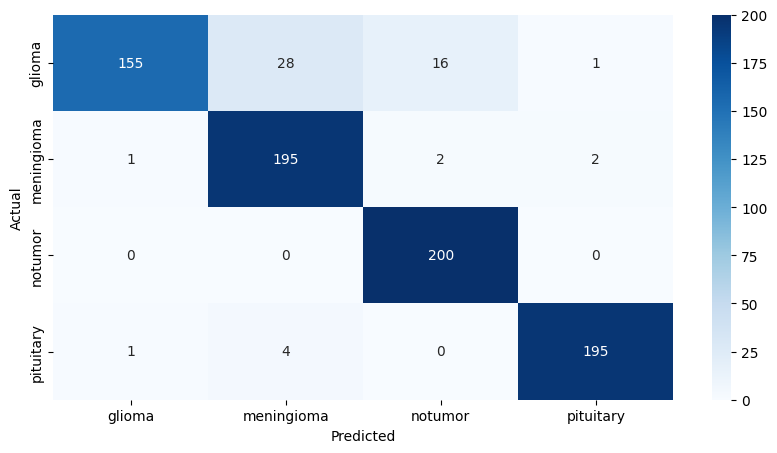

In [16]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

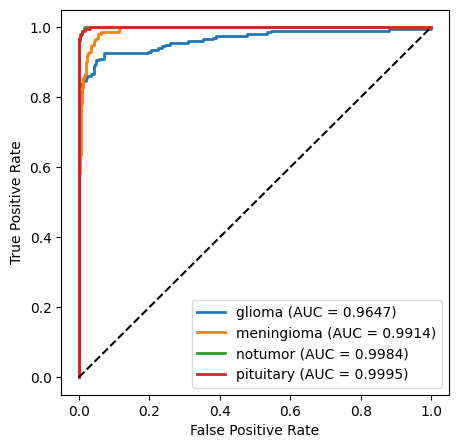

In [18]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

n_classes = len(CLASSES)
y_true_bin = label_binarize(y_true, classes=range(n_classes))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(
        y_true_bin[:, i],
        y_pred_prob[:, i]
    )
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(5,5))

for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        lw=2,
        label=f'{CLASSES[i]} (AUC = {roc_auc[i]:.4f})'
    )

plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# **BCNN : MONTE CARLO DROPOUT**

In [20]:
def build_mc_dropout_model(input_shape=(224,224,3), num_classes=4):
    inputs = tf.keras.Input(shape=input_shape)
    x = inputs

    # Block 1
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.20)(x, training=True)

    # Block 2
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x, training=True)

    # Block 3
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.30)(x, training=True)

    # Block 4
    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.35)(x, training=True)

    # Classifier
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x, training=True)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)
    return model


model_mc = build_mc_dropout_model(num_classes=4)
model_mc.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,243,940 (4.75 MB)

 Trainable params: 1,241,508 (4.74 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [21]:
import time
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(SEED)
model_mc = build_mc_dropout_model(num_classes=4)

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model_mc.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

start_time = time.time()

history_mc = model_mc.fit(
    train_data,
    validation_data=val_data,
    epochs=100,
    callbacks=[early_stop, reduce_lr]
)

end_time = time.time()
elapsed = end_time - start_time

hours, rem = divmod(elapsed, 3600)
minutes, seconds = divmod(rem, 60)
print(f"\nTotal waktu training BCNN MC Dropout: {int(hours)} jam {int(minutes)} menit {seconds:.4f} detik")
print(f"Total epoch aktual: {len(history_mc.history['loss'])}")
print(f"Waktu per epoch: {elapsed / len(history_mc.history['loss']):.4f} detik")

Epoch 1/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 90s 438ms/step - accuracy: 0.6125 - loss: 1.0182 - val_accuracy: 0.3537 - val_loss: 2.0973 - learning_rate: 0.0010
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 76s 434ms/step - accuracy: 0.7503 - loss: 0.6631 - val_accuracy: 0.2725 - val_loss: 4.1034 - learning_rate: 0.0010
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 76s 433ms/step - accuracy: 0.7926 - loss: 0.5508 - val_accuracy: 0.2512 - val_loss: 5.8891 - learning_rate: 0.0010
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 77s 437ms/step - accuracy: 0.8162 - loss: 0.5024 - val_accuracy: 0.6150 - val_loss: 2.0048 - learning_rate: 0.0010
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 76s 434ms/step - accuracy: 0.8456 - loss: 0.4359 - val_accuracy: 0.2500 - val_loss: 6.2000 - learning_rate: 0.0010
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 77s 437ms/step - accuracy: 0.8356 - loss: 0.4447 - val_accuracy: 0.3063 - val_loss: 3.1376 - learning_rate: 0.0010
Epoch 7/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 77s 442ms/step - accura

## **Evaluasi Train**

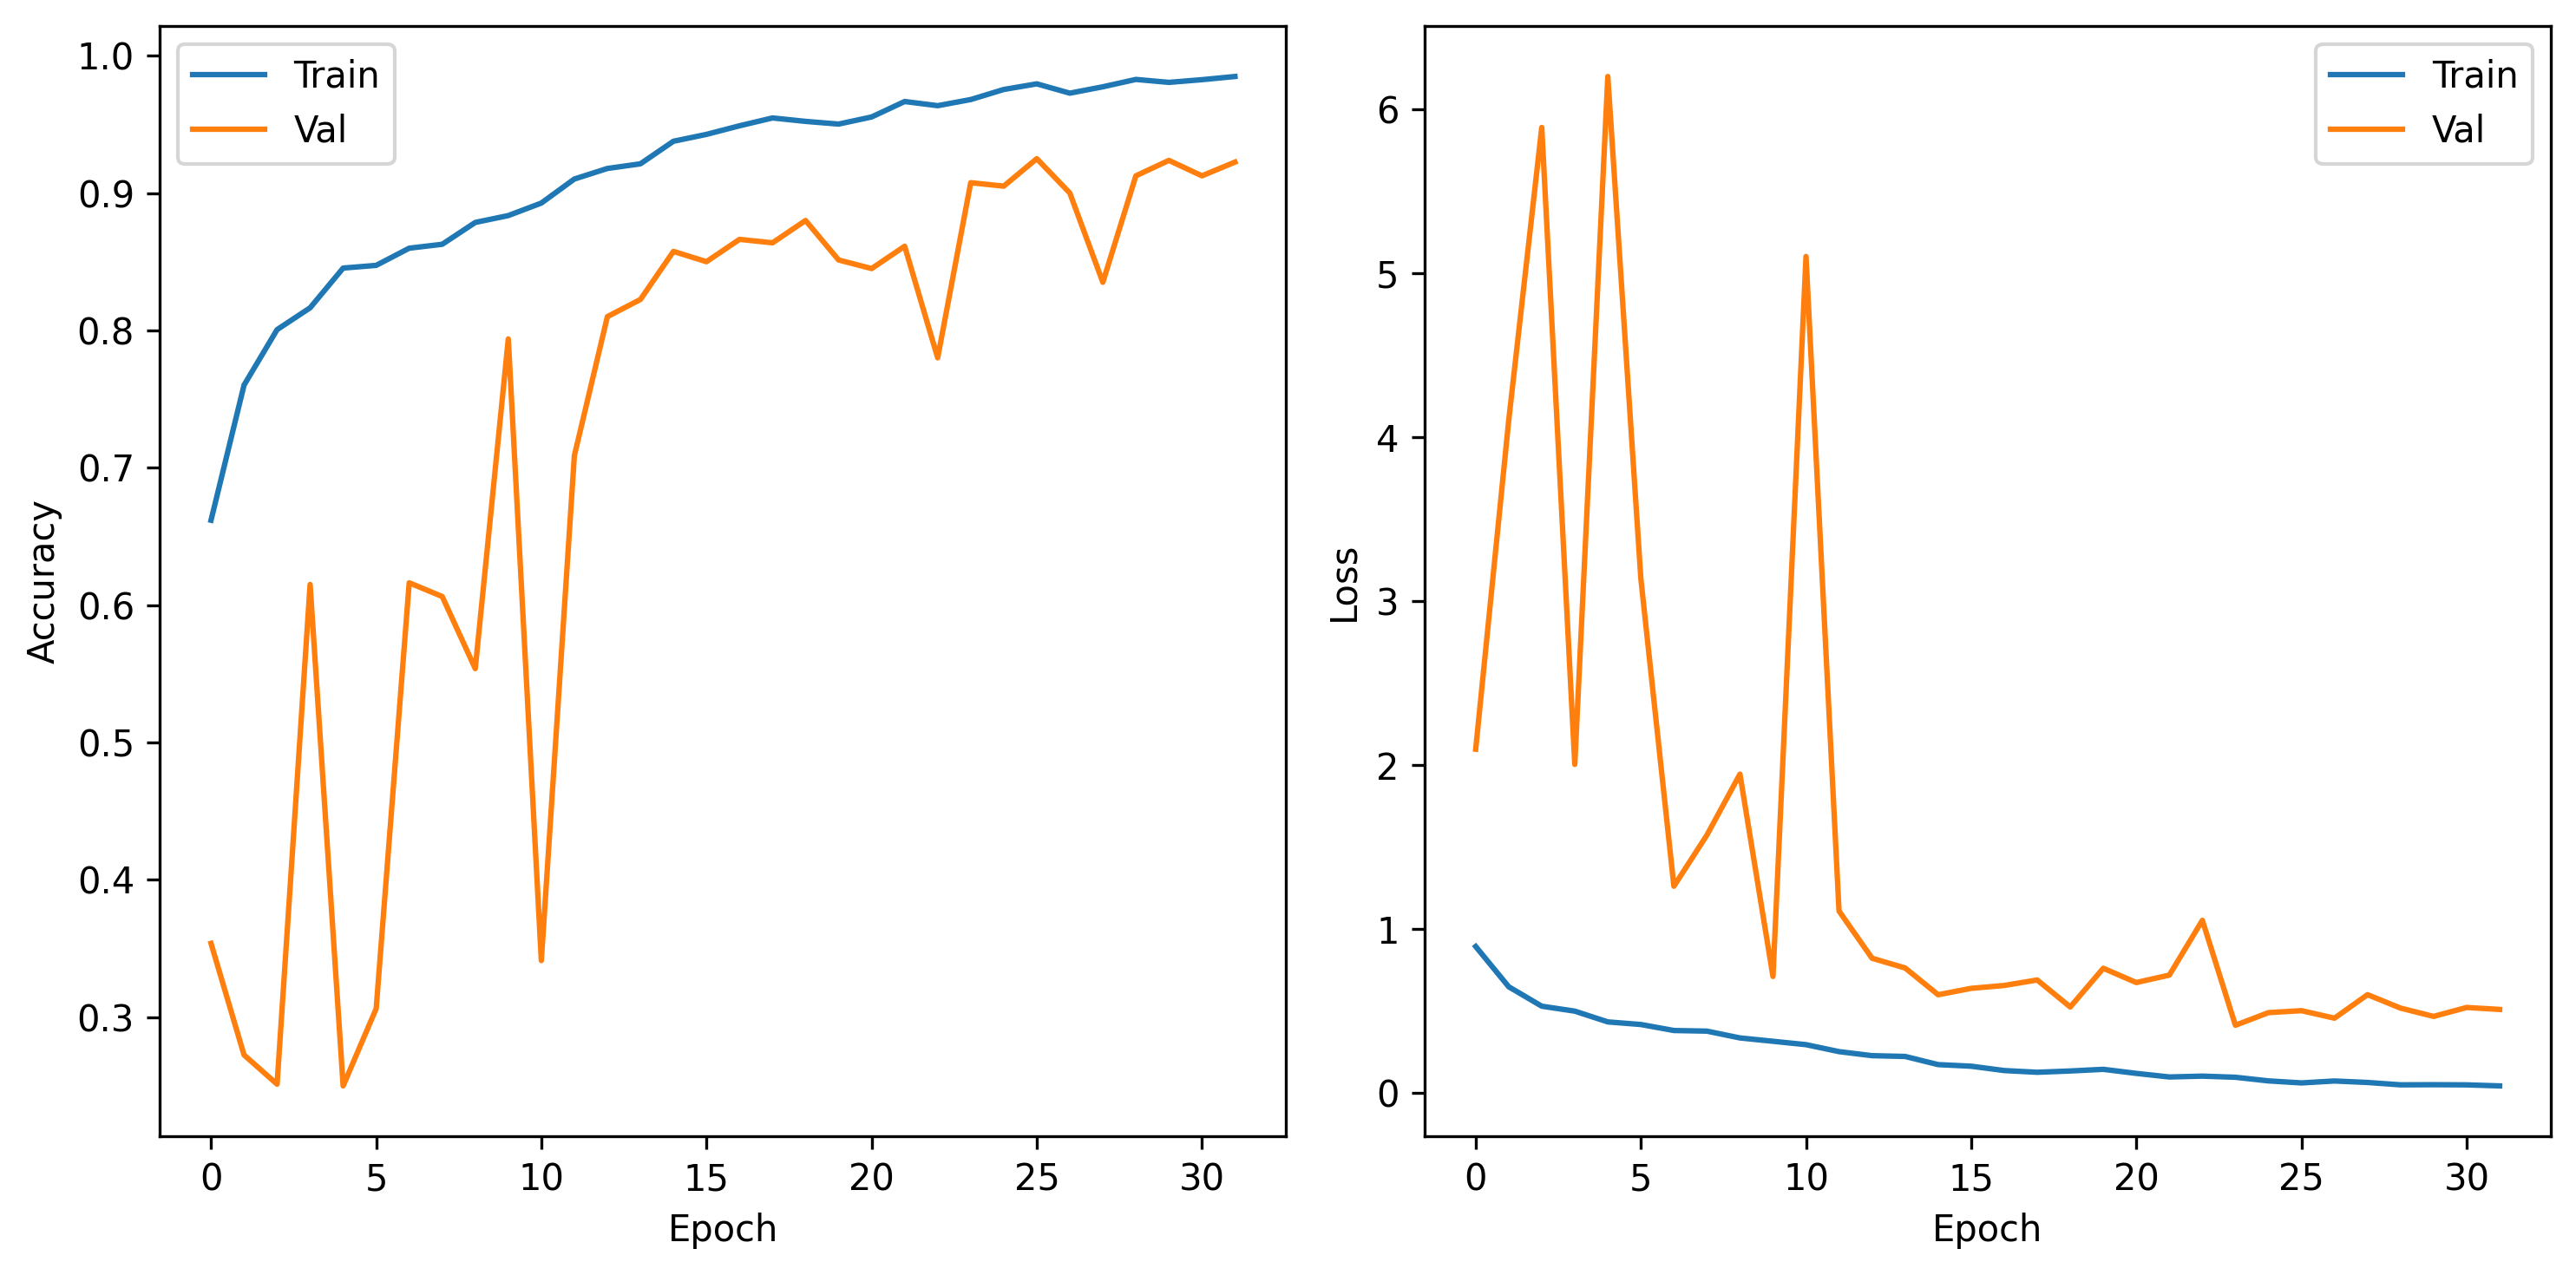

In [22]:
plt.figure(figsize=(10, 5), dpi=300)

plt.subplot(1, 2, 1)
plt.plot(history_mc.history['accuracy'], label='Train')
plt.plot(history_mc.history['val_accuracy'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_mc.history['loss'], label='Train')
plt.plot(history_mc.history['val_loss'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('mc_training_curves.png', dpi=300, bbox_inches=None)
plt.show()

## **Evaluasi Test**

In [24]:
def mc_dropout_predict(model, generator, T=30):
    all_preds = []
    n_batches = len(generator)

    for t in range(T):
        generator.reset()
        preds = []
        for _ in range(n_batches):
            x_batch, _ = next(generator)
            pred = model(x_batch, training=True)
            preds.append(pred.numpy())
        preds = np.concatenate(preds, axis=0)
        all_preds.append(preds)

    all_preds = np.array(all_preds)

    mean_preds = np.mean(all_preds, axis=0)
    std_preds = np.std(all_preds, axis=0)

    return mean_preds, std_preds, all_preds

In [25]:
mean_preds, std_preds, all_preds = mc_dropout_predict(model_mc, test_data, T=30)

y_pred = np.argmax(mean_preds, axis=1)
y_true = test_data.classes  # label asli sesuai urutan generator (shuffle=False)

In [26]:
print(classification_report(y_true, y_pred, target_names=CLASSES, zero_division=0, digits=4))

              precision    recall  f1-score   support

      glioma     0.9593    0.8250    0.8871       200
  meningioma     0.9216    0.9400    0.9307       200
     notumor     0.8969    1.0000    0.9456       200
   pituitary     0.9701    0.9750    0.9726       200

    accuracy                         0.9350       800
   macro avg     0.9370    0.9350    0.9340       800
weighted avg     0.9370    0.9350    0.9340       800



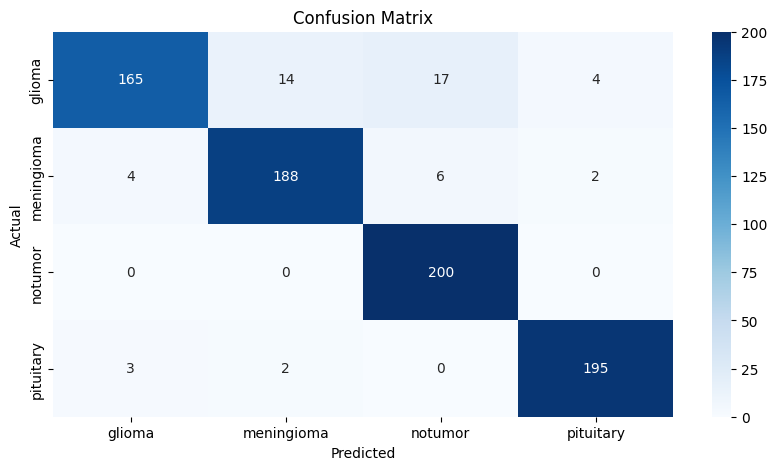

In [27]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

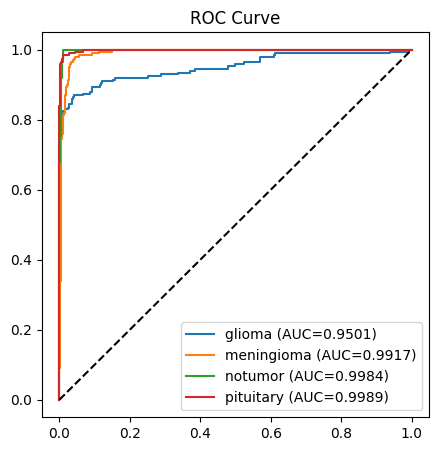

In [28]:
from sklearn.preprocessing import label_binarize
n_classes = len(CLASSES)
y_true_bin = label_binarize(y_true, classes=range(n_classes))

fpr, tpr, roc_auc = {}, {}, {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:,i], mean_preds[:,i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(5,5))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{CLASSES[i]} (AUC={roc_auc[i]:.4f})')

plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve")
plt.show()

In [29]:
y_pred_labels = np.argmax(mean_preds, axis=1)
test_acc_mc = np.mean(y_pred_labels == y_true)

best_epoch = np.argmin(history_mc.history['val_loss'])
train_acc = history_mc.history['accuracy'][best_epoch]
val_acc = history_mc.history['val_accuracy'][best_epoch]

print("\n" + "="*75)
print(f"{'Model':<12} | {'Train Acc (%)':<15} | {'Val Acc (%)':<15} | {'Test Acc (%)':<15}")
print("-"*75)
print(f"{'MC Dropout':<12} | {train_acc*100:<15.4f} | {val_acc*100:<15.4f} | {test_acc_mc*100:<15.4f}")
print("="*75)


Model        | Train Acc (%)   | Val Acc (%)     | Test Acc (%)   
---------------------------------------------------------------------------
MC Dropout   | 96.8036         | 90.7500         | 93.5000        


In [30]:
def compute_entropy(probs):
    return -np.sum(probs * np.log(probs + 1e-10), axis=1)

entropy = compute_entropy(mean_preds)
std_mean = std_preds.mean(axis=1)

## **Evaluasi Uncertainty**

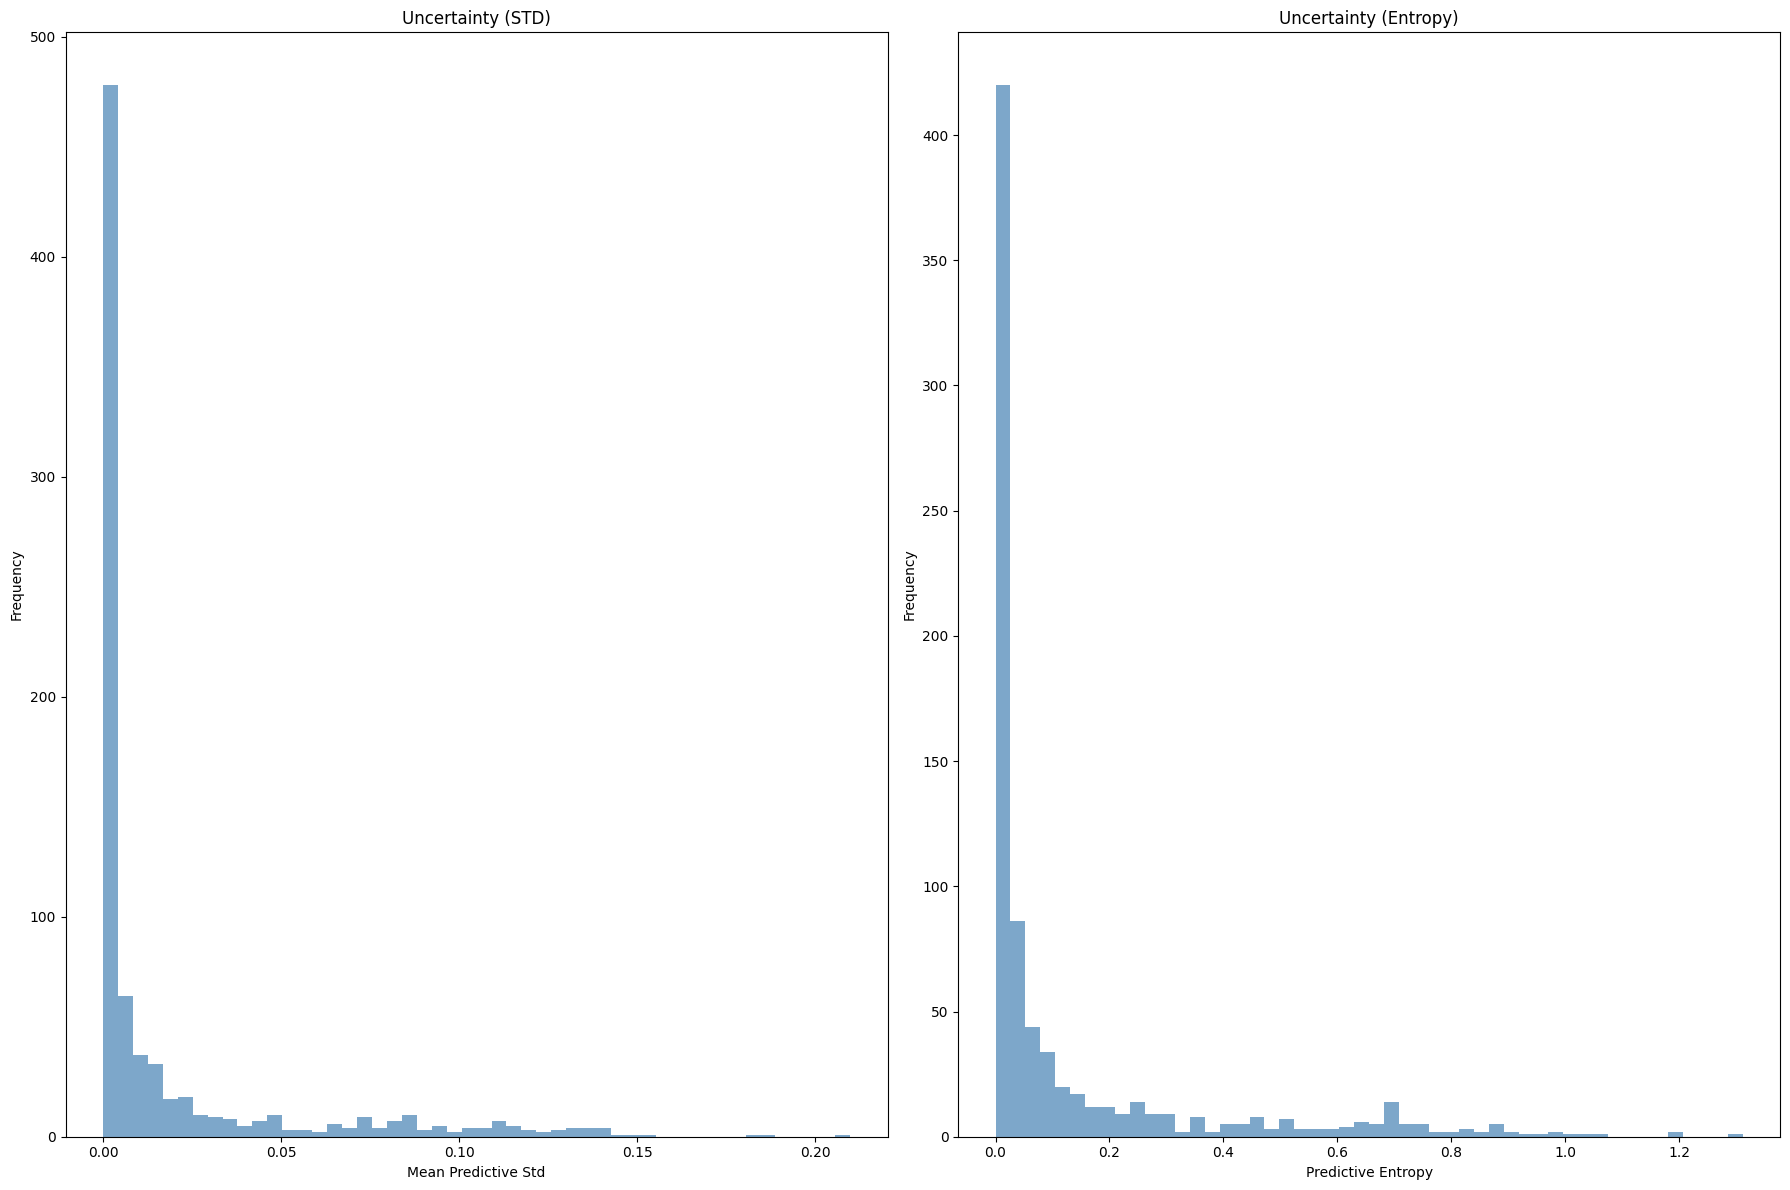

In [31]:
plt.figure(figsize=(18,12))
plt.subplot(1,2,1)
plt.hist(std_mean, bins=50, alpha=0.7, color='steelblue')
plt.title("Uncertainty (STD)")
plt.xlabel("Mean Predictive Std")
plt.ylabel("Frequency")
plt.subplot(1,2,2)

plt.hist(entropy, bins=50, alpha=0.7, color='steelblue')
plt.title("Uncertainty (Entropy)")
plt.xlabel("Predictive Entropy")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [32]:
entropy_per_class = {}

# Pastikan y_true adalah numpy array agar perbandingan elemen-demi-elemen (broadcasting) berjalan
y_true_arr = np.array(y_true)

for i, cls in enumerate(CLASSES):
    # Sekarang perbandingan ini akan menghasilkan array boolean [True, False, True, ...]
    idx = np.where(y_true_arr == i)[0]
    
    # Menghitung mean jika indeks tidak kosong untuk menghindari warning
    if len(idx) > 0:
        entropy_per_class[cls] = entropy[idx].mean()
    else:
        entropy_per_class[cls] = 0.0

df_entropy = pd.DataFrame({
    'Class': list(entropy_per_class.keys()),
    'Mean Entropy': list(entropy_per_class.values())
})

print(df_entropy.sort_values(by='Mean Entropy', ascending=False))

        Class  Mean Entropy
1  meningioma      0.236012
0      glioma      0.172915
3   pituitary      0.078799
2     notumor      0.038135


In [33]:
correct_mask = (y_pred == y_true)

print(f"Mean entropy (correct predictions): {entropy[correct_mask].mean():.4f}")
print(f"Mean entropy (incorrect predictions): {entropy[~correct_mask].mean():.4f}")

print(f"Mean std (correct predictions): {std_mean[correct_mask].mean():.4f}")
print(f"Mean std (incorrect predictions): {std_mean[~correct_mask].mean():.4f}")

Mean entropy (correct predictions): 0.0989
Mean entropy (incorrect predictions): 0.6005
Mean std (correct predictions): 0.0133
Mean std (incorrect predictions): 0.0890


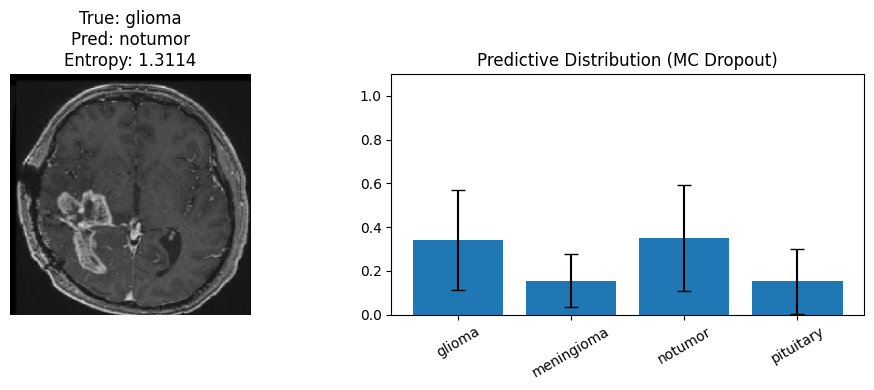

In [34]:
test_data.reset()
all_images = np.concatenate([next(test_data)[0] for _ in range(len(test_data))], axis=0)

def plot_mc_prediction(index):
    img = all_images[index]
    lbl = y_true[index]

    sample_preds = all_preds[:, index, :]

    mean_p = sample_preds.mean(axis=0)
    std_p  = sample_preds.std(axis=0)

    pred = np.argmax(mean_p)
    entropy_val = -np.sum(mean_p * np.log(mean_p + 1e-10))

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title(f"True: {CLASSES[lbl]}\nPred: {CLASSES[pred]}\nEntropy: {entropy_val:.4f}")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.bar(CLASSES, mean_p, yerr=std_p, capsize=5)
    plt.ylim(0,1.1)
    plt.title("Predictive Distribution (MC Dropout)")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()

plot_mc_prediction(np.argmax(entropy))

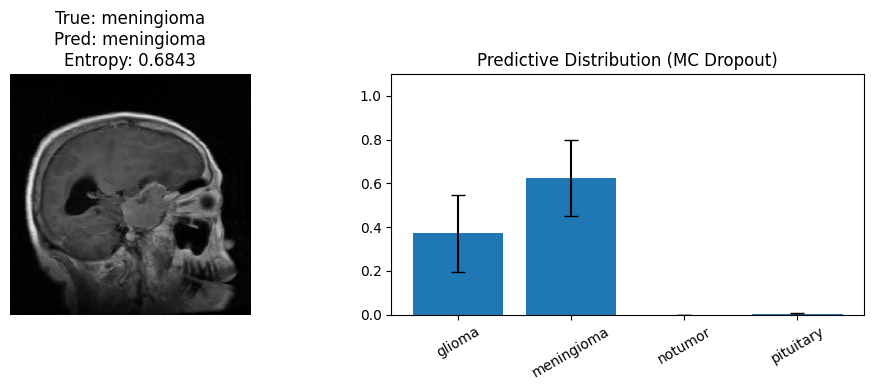

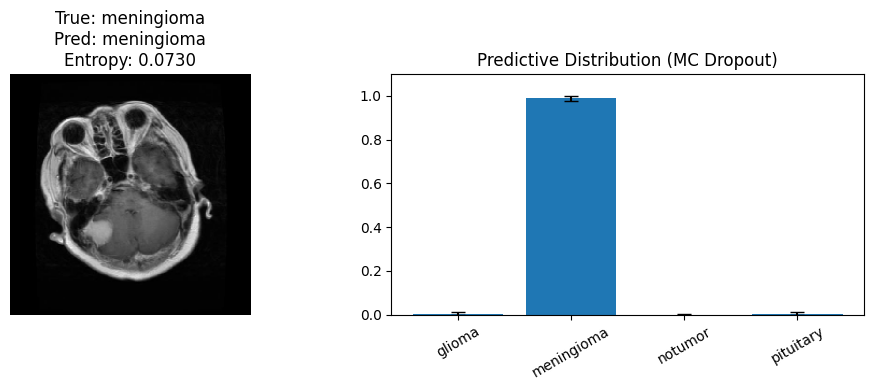

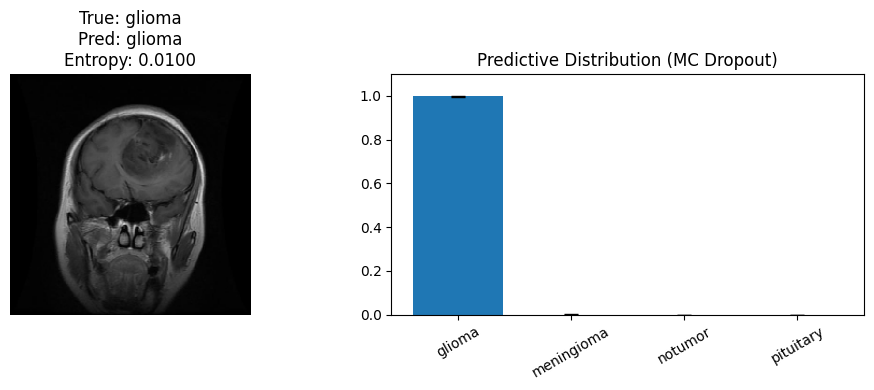

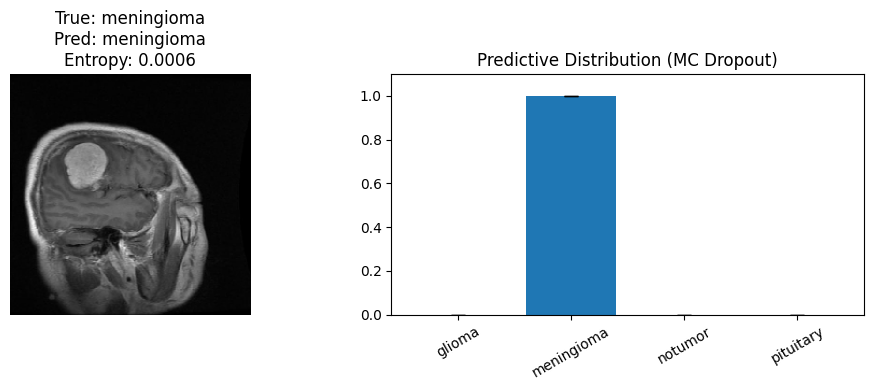

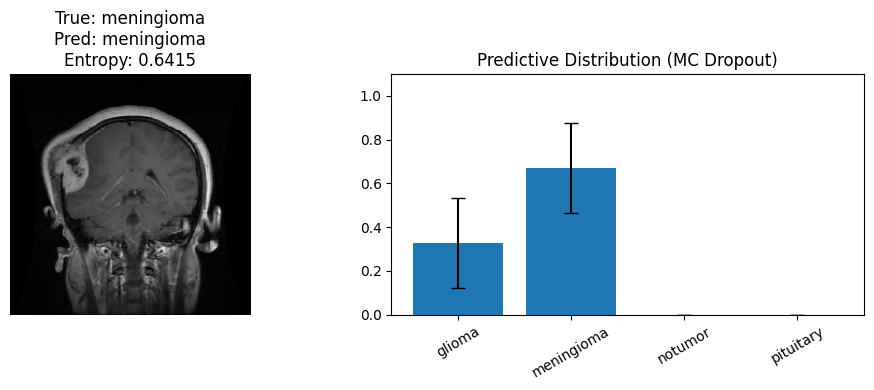

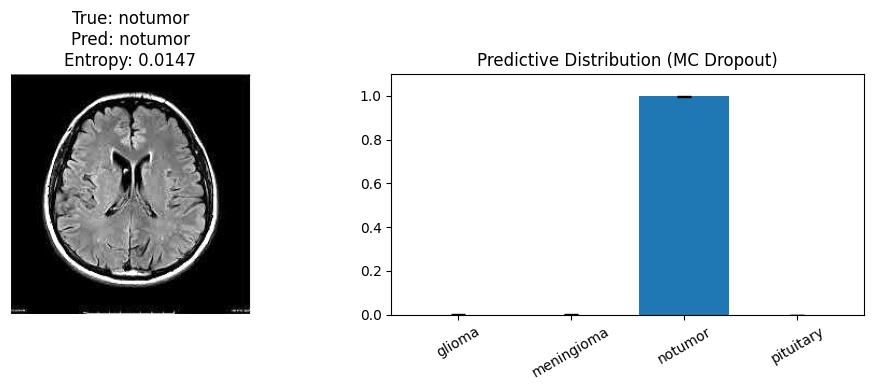

In [35]:
plot_mc_prediction(0)
plot_mc_prediction(1)
plot_mc_prediction(2)
plot_mc_prediction(3)
plot_mc_prediction(4)
plot_mc_prediction(5)

### Uncertainty Tertinggi

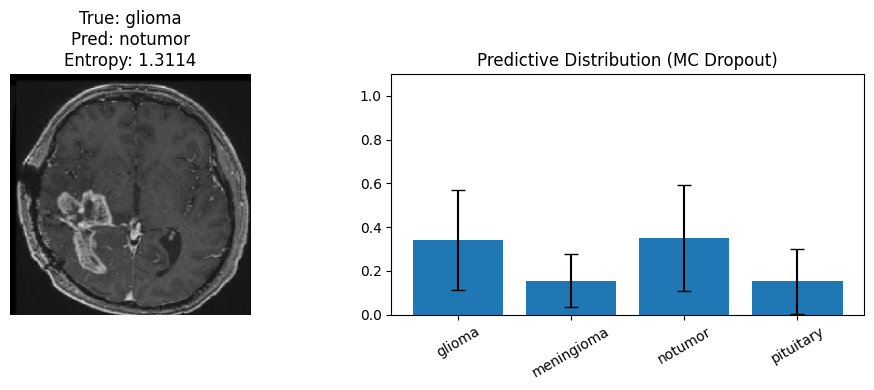

In [36]:
plot_mc_prediction(np.argmax(entropy))

### Uncertainty Terendah

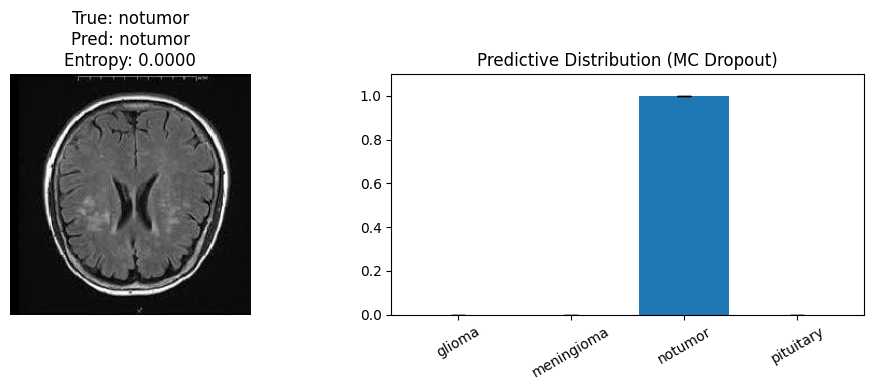

In [37]:
plot_mc_prediction(np.argmin(entropy))

# **BCNN : VARIATIONAL INFERENCE**

In [38]:
!pip install tf_keras

In [39]:
import os
# Wajib dieksekusi pertama kali sebelum mengimpor tensorflow
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
import tensorflow_probability as tfp
import tf_keras as keras
from tf_keras import layers
import time

tfpl = tfp.layers
tfd = tfp.distributions

# Jumlah data training (diambil dari generator, bukan unbatch tf.data)
NUM_TRAIN_EXAMPLES = train_data.samples
print(f"Jumlah data training: {NUM_TRAIN_EXAMPLES}")

KL_WEIGHT = 1e-5

def kl_divergence_fn(q, p, _):
    return KL_WEIGHT * tfd.kl_divergence(q, p) / tf.cast(NUM_TRAIN_EXAMPLES, tf.float32)

def build_bcnn_vi(input_shape=(224, 224, 3), num_classes=4):
    inputs = keras.Input(shape=input_shape)

    posterior_fn = tfpl.default_mean_field_normal_fn()
    prior_fn = tfpl.default_multivariate_normal_fn

    x = inputs

    # Backbone disamakan dengan CNN biasa & BCNN-MC Dropout (VGG-style)
    filters_list = [32, 64, 128, 256]
    dropout_rates = [0.20, 0.25, 0.30, 0.35]

    for filters, drop_rate in zip(filters_list, dropout_rates):
        x = tfpl.Convolution2DFlipout(
            filters, 3, padding='same', activation='relu',
            kernel_posterior_fn=posterior_fn,
            kernel_prior_fn=prior_fn,
            kernel_divergence_fn=kl_divergence_fn
        )(x)
        x = layers.BatchNormalization()(x)
        x = tfpl.Convolution2DFlipout(
            filters, 3, padding='same', activation='relu',
            kernel_posterior_fn=posterior_fn,
            kernel_prior_fn=prior_fn,
            kernel_divergence_fn=kl_divergence_fn
        )(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D(2)(x)
        x = layers.Dropout(drop_rate)(x)

    # ===== CLASSIFIER =====
    x = layers.GlobalAveragePooling2D()(x)

    x = tfpl.DenseFlipout(
        256, activation='relu',
        kernel_posterior_fn=posterior_fn,
        kernel_prior_fn=prior_fn,
        kernel_divergence_fn=kl_divergence_fn
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    logits = tfpl.DenseFlipout(
        num_classes,
        kernel_posterior_fn=posterior_fn,
        kernel_prior_fn=prior_fn,
        kernel_divergence_fn=kl_divergence_fn
    )(x)

    logits = tf.clip_by_value(logits, -10, 10)

    outputs = layers.Softmax()(logits)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

Jumlah data training: 5600


In [40]:
tf.random.set_seed(SEED)
model_vi = build_bcnn_vi(num_classes=4)
model_vi.summary()

optimizer = keras.optimizers.Adam(learning_rate=1e-3)

model_vi.compile(
    optimizer=optimizer,
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=16,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)

start_time = time.time()

history_vi = model_vi.fit(
    train_data,
    validation_data=val_data,
    steps_per_epoch=len(train_data),
    validation_steps=len(val_data),
    epochs=100,
    callbacks=[early_stop, reduce_lr]
)

end_time = time.time()
elapsed = end_time - start_time
hours, rem = divmod(elapsed, 3600)
minutes, seconds = divmod(rem, 60)

print(f"\nTotal waktu training BCNN VI: {int(hours)} jam {int(minutes)} menit {seconds:.4f} detik")
print(f"Total epoch aktual: {len(history_vi.history['loss'])}")
print(f"Waktu per epoch: {elapsed / len(history_vi.history['loss']):.4f} detik")

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv2d_flipout (Conv2DFlip  (None, 224, 224, 32)      1760      
 out)                                                            
                                                                 
 batch_normalization (Batch  (None, 224, 224, 32)      128       
 Normalization)                                                  
                                                                 
 conv2d_flipout_1 (Conv2DFl  (None, 224, 224, 32)      18464     
 ipout)                                                          
                                                                 
 batch_normalization_1 (Bat  (None, 224, 224, 32)      128       
 chNormalization)                                            

E0000 00:00:1782054578.845252      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


175/175 [==============================] - 99s 472ms/step - loss: 1.7154 - accuracy: 0.4379 - val_loss: 2.4961 - val_accuracy: 0.3137 - lr: 0.0010
Epoch 2/100
175/175 [==============================] - 82s 469ms/step - loss: 1.2515 - accuracy: 0.5230 - val_loss: 1.6764 - val_accuracy: 0.3825 - lr: 0.0010
Epoch 3/100
175/175 [==============================] - 84s 478ms/step - loss: 1.0810 - accuracy: 0.5852 - val_loss: 1.3570 - val_accuracy: 0.4837 - lr: 0.0010
Epoch 4/100
175/175 [==============================] - 84s 483ms/step - loss: 0.9845 - accuracy: 0.6086 - val_loss: 1.2682 - val_accuracy: 0.5400 - lr: 0.0010
Epoch 5/100
175/175 [==============================] - 84s 483ms/step - loss: 0.9213 - accuracy: 0.6359 - val_loss: 1.1695 - val_accuracy: 0.6125 - lr: 0.0010
Epoch 6/100
175/175 [==============================] - 84s 483ms/step - loss: 0.8659 - accuracy: 0.6555 - val_loss: 1.0797 - val_accuracy: 0.6187 - lr: 0.0010
Epoch 7/100
175/175 [==============================] - 84s

## **Evaluasi Train**

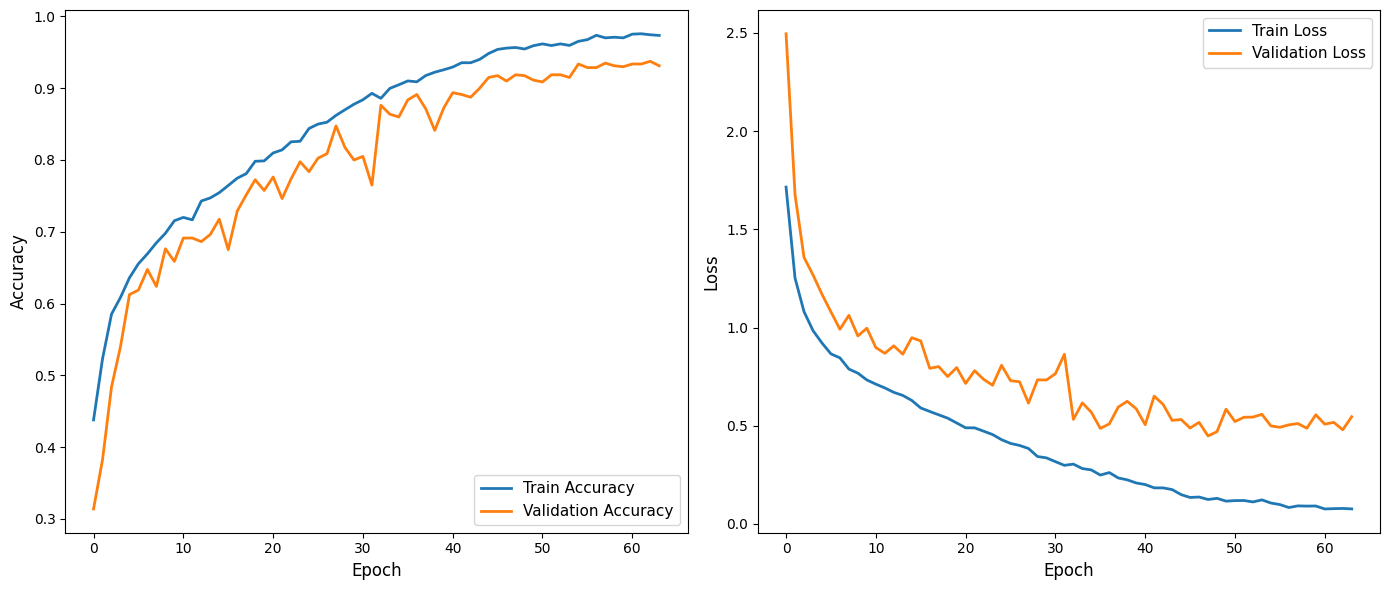

In [49]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history_vi.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history_vi.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right', fontsize=11)

plt.subplot(1, 2, 2)
plt.plot(history_vi.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history_vi.history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

## **Evaluasi Test**

In [42]:
def predict_with_uncertainty(model, generator, T=30):
    """
    Melakukan T forward pass stokastik (Flipout sampling) untuk estimasi
    mean prediction dan uncertainty (std) dari BCNN-VI.
    Generator di-reset di awal DAN akhir fungsi, supaya pemanggil tidak perlu
    mengingat reset manual untuk operasi berikutnya (evaluate, plotting, dll).
    """
    n_batches = len(generator)

    generator.reset()
    y_true_collected = generator.classes  # urutan label sesuai shuffle=False

    all_preds = []
    for t in range(T):
        generator.reset()
        preds_T = []
        for _ in range(n_batches):
            x_batch, _ = next(generator)
            # training=False aman untuk Flipout (sampling tetap terjadi otomatis),
            # tapi pastikan tidak ada Dropout lain di model yang ikut nonaktif
            # kalau memang ingin dropout ikut berkontribusi ke uncertainty
            pred = model(x_batch, training=False)
            preds_T.append(pred.numpy())
        preds_T = np.concatenate(preds_T, axis=0)
        all_preds.append(preds_T)

    all_preds = np.array(all_preds)  # Shape: (T, N, num_classes)
    mean_pred = all_preds.mean(axis=0)
    std_pred = all_preds.std(axis=0)

    generator.reset()  # pastikan generator kembali ke posisi awal untuk pemanggil berikutnya

    return mean_pred, y_true_collected, std_pred


# Jalankan prediksi
y_pred_prob, y_true_class, y_uncertainty = predict_with_uncertainty(model_vi, test_data, T=30)

# Konversi probabilitas ke label kelas (0, 1, 2, 3)
y_pred_class = np.argmax(y_pred_prob, axis=1)

# Evaluasi standar Keras (hanya 1x forward pass)
test_data.reset()  # tetap dipertahankan untuk kejelasan, walau fungsi di atas sudah reset di akhir
test_loss, test_acc = model_vi.evaluate(test_data, steps=len(test_data))

# Evaluasi Ensemble/Bayesian (T=30 forward pass)
from sklearn.metrics import accuracy_score
ensemble_acc = accuracy_score(y_true_class, y_pred_class)

print(f"\nTest Loss (Single Pass): {test_loss:.4f}")
print(f"Test Accuracy (Single Pass): {test_acc:.4f}")
print(f"Ensemble Accuracy (T=30 Passes): {ensemble_acc:.4f}")

25/25 [==============================] - 3s 111ms/step - loss: 0.3503 - accuracy: 0.9287

Test Loss (Single Pass): 0.3503
Test Accuracy (Single Pass): 0.9287
Ensemble Accuracy (T=30 Passes): 0.9363


In [43]:
print(classification_report(y_true_class, y_pred_class, target_names=CLASSES))

              precision    recall  f1-score   support

      glioma       0.98      0.81      0.89       200
  meningioma       0.89      0.94      0.91       200
     notumor       0.90      0.99      0.95       200
   pituitary       0.98      1.00      0.99       200

    accuracy                           0.94       800
   macro avg       0.94      0.94      0.94       800
weighted avg       0.94      0.94      0.94       800



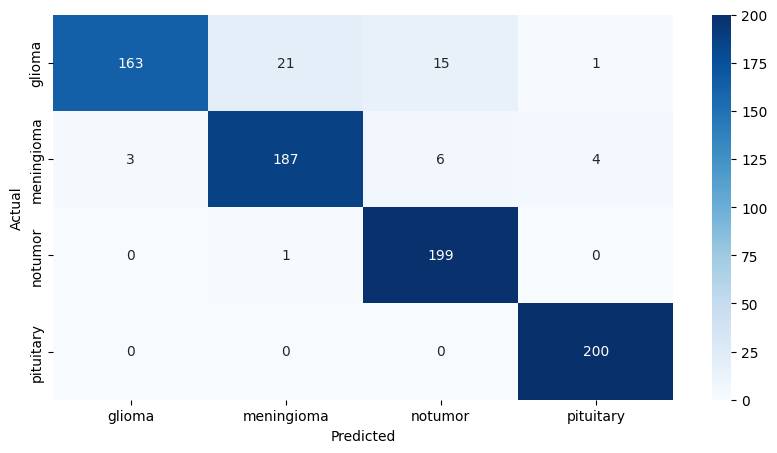

In [48]:
cm = confusion_matrix(y_true_class, y_pred_class)

plt.figure(figsize=(10,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

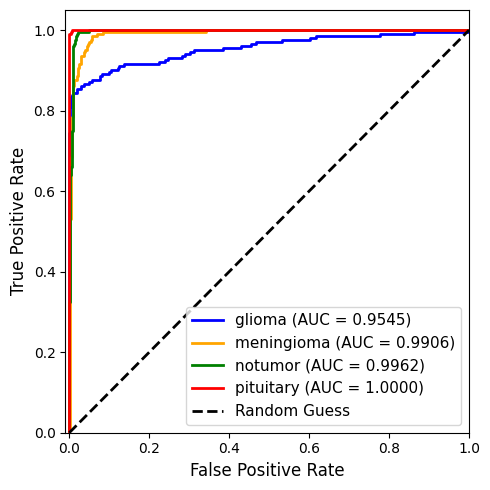

In [51]:
from sklearn.preprocessing import label_binarize

n_classes = len(CLASSES)
y_true_bin = label_binarize(y_true_class, classes=range(n_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(5, 5))

colors = ['blue', 'orange', 'green', 'red']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{CLASSES[i]} (AUC = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')

plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc="lower right", fontsize=11)

plt.tight_layout()
plt.show()

In [52]:
y_pred_labels = np.argmax(y_pred_prob, axis=1)
test_acc_vi = np.mean(y_pred_labels == y_true_class)

best_epoch = np.argmin(history_vi.history['val_loss'])
train_acc = history_vi.history['accuracy'][best_epoch]
val_acc = history_vi.history['val_accuracy'][best_epoch]

print("\n" + "="*75)
print(f"{'Model':<12} | {'Train Acc (%)':<15} | {'Val Acc (%)':<15} | {'Test Acc (%)':<15}")
print("-"*75)
print(f"{'BCNN VI':<12} | {train_acc*100:<15.4f} | {val_acc*100:<15.4f} | {test_acc_vi*100:<15.4f}")
print("="*75)


Model        | Train Acc (%)   | Val Acc (%)     | Test Acc (%)   
---------------------------------------------------------------------------
BCNN VI      | 95.6786         | 91.8750         | 93.6250        


In [53]:
def compute_entropy(probs):
    return -np.sum(probs * np.log(probs + 1e-10), axis=1)

entropy_vi = compute_entropy(y_pred_prob)
std_mean_vi = y_uncertainty.mean(axis=1)
print(f"Rata-rata Entropy dataset (VI/Flipout): {entropy_vi.mean():.4f}")
print(f"Rata-rata Standar Deviasi dataset (VI/Flipout): {std_mean_vi.mean():.4f}")

Rata-rata Entropy dataset (VI/Flipout): 0.1215
Rata-rata Standar Deviasi dataset (VI/Flipout): 0.0162


## **Evaluasi Uncertainty**

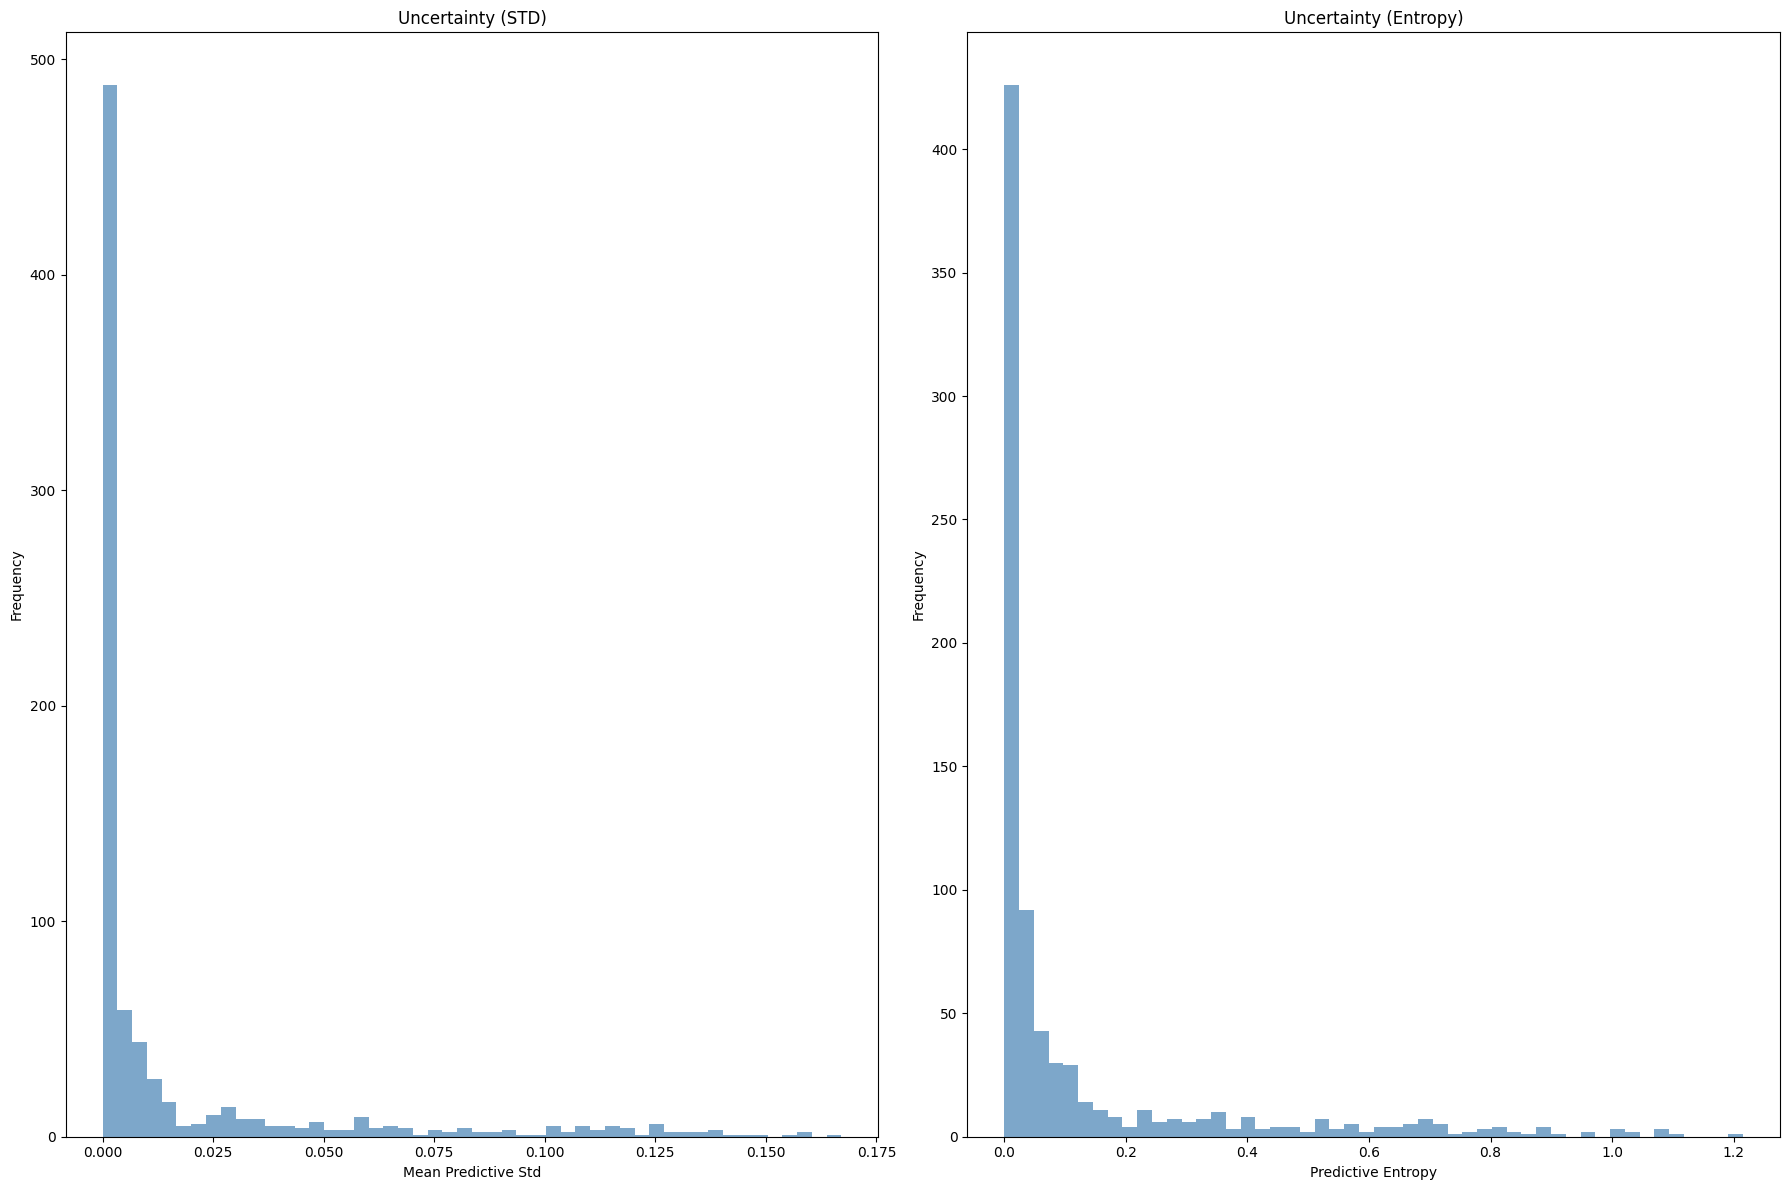

In [54]:
plt.figure(figsize=(18, 12))

plt.subplot(1, 2, 1)
plt.hist(std_mean_vi, bins=50, alpha=0.7, color='steelblue')
plt.title("Uncertainty (STD)")
plt.xlabel("Mean Predictive Std")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(entropy_vi, bins=50, alpha=0.7, color='steelblue')
plt.title("Uncertainty (Entropy)")
plt.xlabel("Predictive Entropy")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [55]:
entropy_per_class_vi = {}
y_true_arr = np.array(y_true_class)  # cast ke numpy array dulu
for i, cls in enumerate(CLASSES):
    idx = np.where(y_true_arr == i)[0]
    if len(idx) > 0:
        entropy_per_class_vi[cls] = entropy_vi[idx].mean()
    else:
        entropy_per_class_vi[cls] = 0.0

df_entropy_vi = pd.DataFrame({
    'Class': list(entropy_per_class_vi.keys()),
    'Mean Entropy': list(entropy_per_class_vi.values())
})
print("\n--- Mean Entropy Per Class (VI/Flipout) ---")
print(df_entropy_vi.sort_values(by='Mean Entropy', ascending=False))


--- Mean Entropy Per Class (VI/Flipout) ---
        Class  Mean Entropy
0      glioma      0.191817
1  meningioma      0.187096
3   pituitary      0.063015
2     notumor      0.043937


In [56]:
correct_mask = (y_pred_class == y_true_class)

print("\n--- Uncertainty Analysis (Correct vs Incorrect) ---")
print(f"Mean entropy (correct predictions):   {entropy_vi[correct_mask].mean():.4f}")
print(f"Mean entropy (incorrect predictions): {entropy_vi[~correct_mask].mean():.4f}")

print(f"\nMean std (correct predictions):       {std_mean_vi[correct_mask].mean():.4f}")
print(f"Mean std (incorrect predictions):     {std_mean_vi[~correct_mask].mean():.4f}")


--- Uncertainty Analysis (Correct vs Incorrect) ---
Mean entropy (correct predictions):   0.0891
Mean entropy (incorrect predictions): 0.5969

Mean std (correct predictions):       0.0111
Mean std (incorrect predictions):     0.0904


In [57]:
test_data.reset()
all_images = np.concatenate([next(test_data)[0] for _ in range(len(test_data))], axis=0)

def plot_vi_prediction(index):
    img = all_images[index]
    lbl = y_true_class[index]

    mean_p = y_pred_prob[index]
    std_p  = y_uncertainty[index]

    pred = y_pred_class[index]
    entropy_val = entropy_vi[index]

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"True: {CLASSES[lbl]}\nPred: {CLASSES[pred]}\nEntropy: {entropy_val:.4f}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.bar(CLASSES, mean_p, yerr=std_p, capsize=5, alpha=0.8)
    plt.ylim(0, 1.1)
    plt.title("Predictive Distribution (BCNN VI)")

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

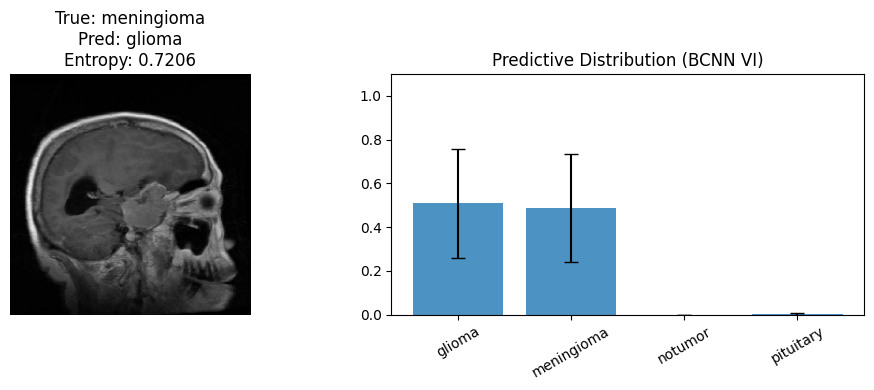

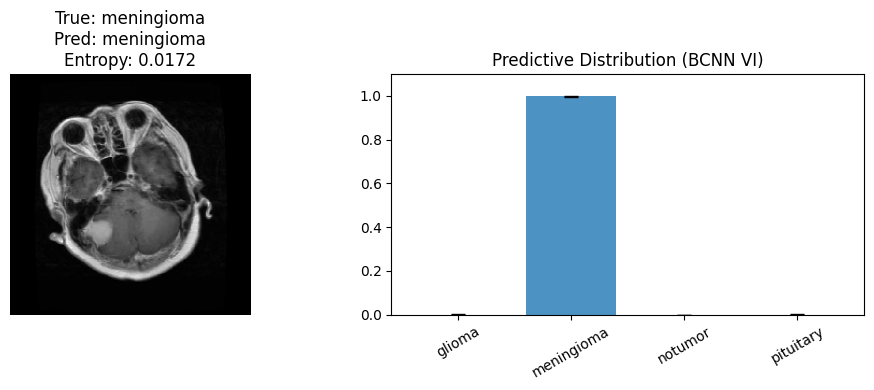

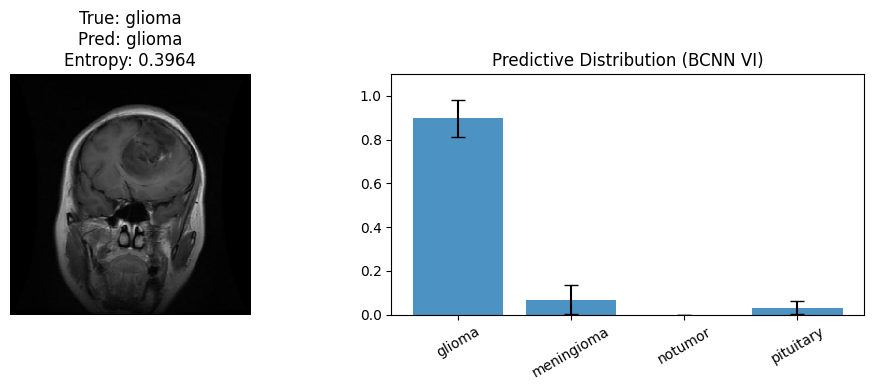

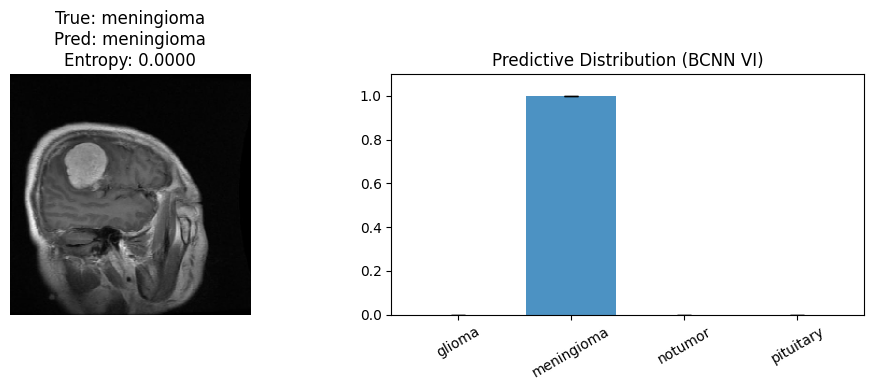

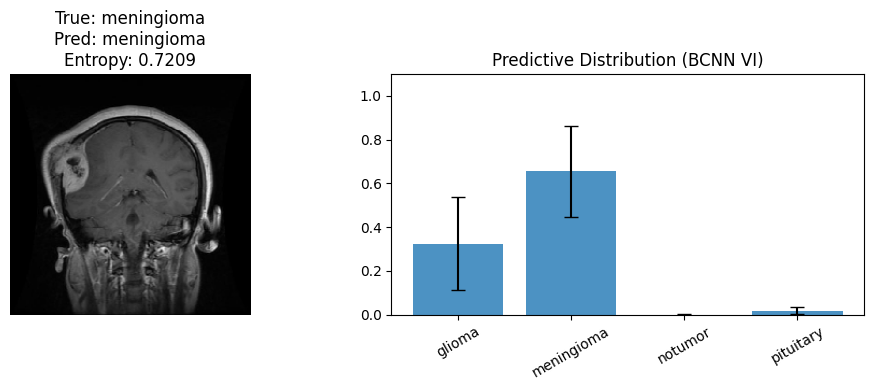

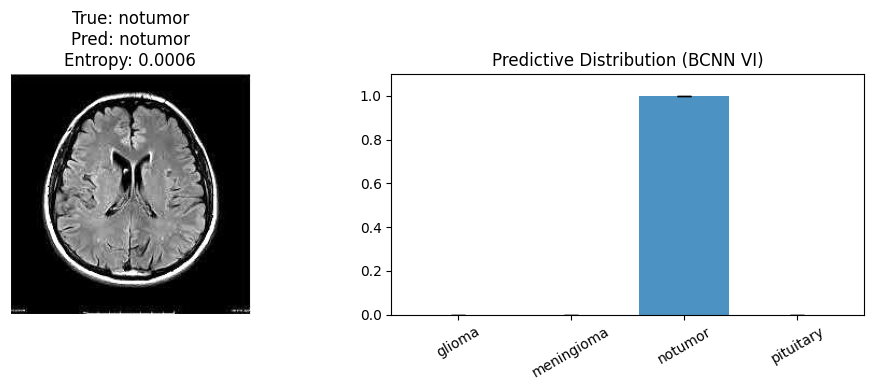

In [58]:
plot_vi_prediction(0)
plot_vi_prediction(1)
plot_vi_prediction(2)
plot_vi_prediction(3)
plot_vi_prediction(4)
plot_vi_prediction(5)

### Uncertainty Tertinggi

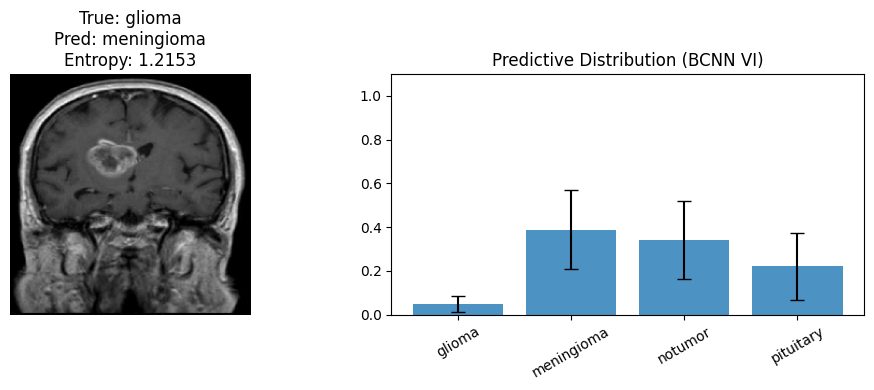

In [59]:
plot_vi_prediction(np.argmax(entropy_vi))

### Uncertainty Terendah

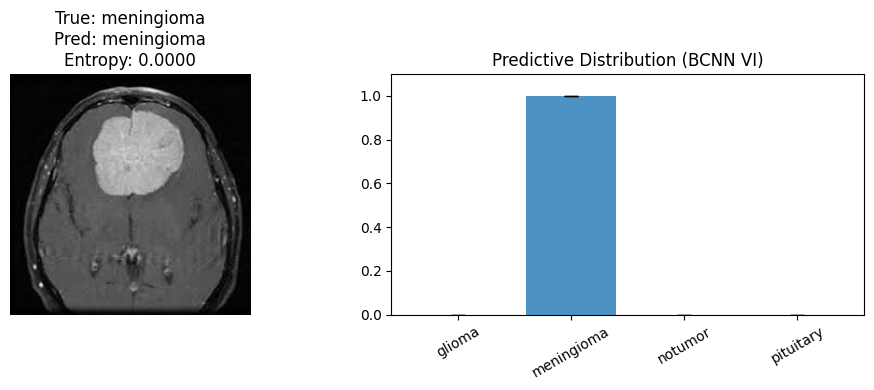

In [60]:
plot_vi_prediction(np.argmin(entropy_vi))

# **PERBANDINGAN KEDUANYA**

In [61]:
# Gabungkan statistik deskriptif Entropy & Std Mean untuk MC Dropout dan VI dalam 1 tabel
desc_stats = pd.DataFrame({
    'Entropy (MC Dropout)': pd.Series(entropy).describe(),
    'Entropy (VI)': pd.Series(entropy_vi).describe(),
    'Std Mean (MC Dropout)': pd.Series(std_mean).describe(),
    'Std Mean (VI)': pd.Series(std_mean_vi).describe(),
})

# Tambahkan median secara eksplisit (describe() default cuma kasih 50% sebagai proxy median, sudah termasuk -- ini cuma rename biar lebih jelas dibaca)
desc_stats = desc_stats.rename(index={'50%': 'median'})

print("--- Statistik Deskriptif: Entropy & Std Mean (MC Dropout vs VI) ---")
display(desc_stats.round(4))

--- Statistik Deskriptif: Entropy & Std Mean (MC Dropout vs VI) ---


,Entropy (MC Dropout),Entropy (VI),Std Mean (MC Dropout),Std Mean (VI)
count,800.0000,800.0000,800.0000,800.0000
mean,0.1315,0.1215,0.0182,0.0162
std,0.2314,0.2256,0.0345,0.0327
min,0.0000,0.0000,0.0000,0.0000
25%,0.0041,0.0023,0.0004,0.0001
median,0.0221,0.0168,0.0022,0.0014
75%,0.1244,0.1038,0.0152,0.0114
max,1.3114,1.2153,0.2099,0.1671


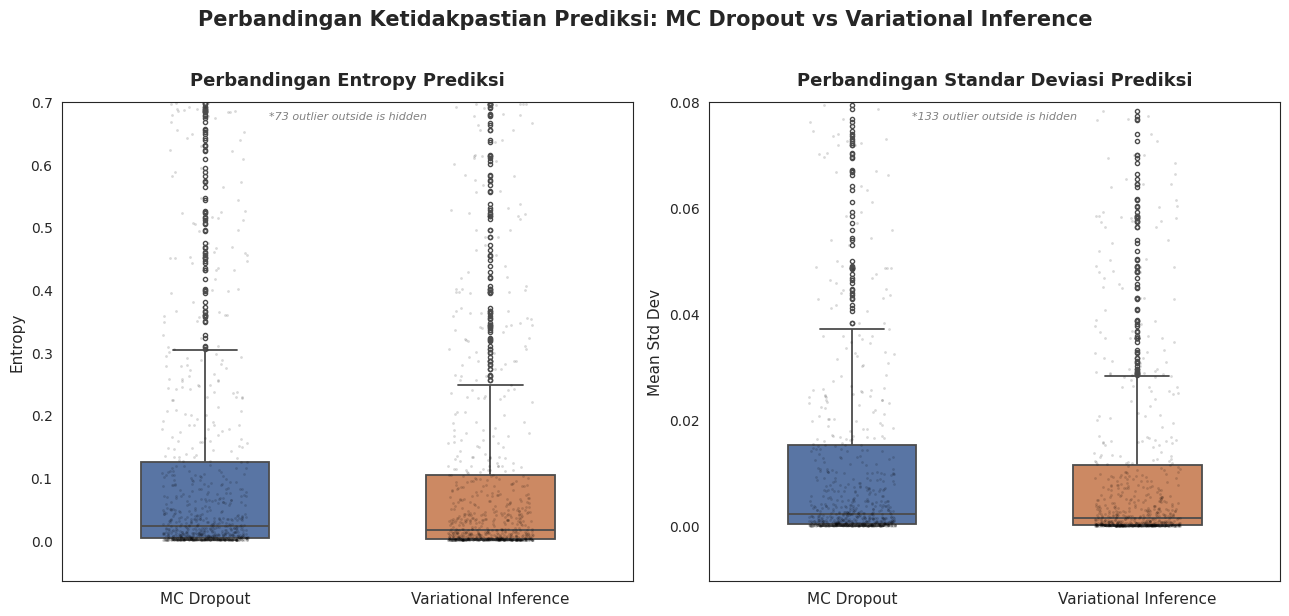

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Susun data ke long-format DataFrame supaya gampang diplot seaborn
df_entropy_compare = pd.DataFrame({
    'Entropy': np.concatenate([entropy, entropy_vi]),
    'Model': ['MC Dropout'] * len(entropy) + ['Variational Inference'] * len(entropy_vi)
})

df_std_compare = pd.DataFrame({
    'Std Mean': np.concatenate([std_mean, std_mean_vi]),
    'Model': ['MC Dropout'] * len(std_mean) + ['Variational Inference'] * len(std_mean_vi)
})

# Batas atas y-axis
ENTROPY_YLIM = 0.7
STD_YLIM = 0.08

sns.set_style('white')  # ganti dari 'whitegrid' -> 'white' (tanpa garis grid)
palette = {'MC Dropout': '#4C72B0', 'Variational Inference': '#DD8452'}

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# --- Boxplot 1: Entropy ---
sns.boxplot(
    data=df_entropy_compare, x='Model', y='Entropy',
    hue='Model', palette=palette, legend=False,
    width=0.45, linewidth=1.3, fliersize=3,
    ax=axes[0]
)
sns.stripplot(
    data=df_entropy_compare, x='Model', y='Entropy',
    color='black', alpha=0.15, size=2, jitter=0.15,
    ax=axes[0]
)
axes[0].set_title('Perbandingan Entropy Prediksi', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Entropy', fontsize=11)
axes[0].tick_params(axis='x', labelsize=11)
axes[0].set_ylim(top=ENTROPY_YLIM)
axes[0].grid(False)  # pastikan grid mati meskipun style lain mengaktifkannya

n_cut_entropy = (df_entropy_compare['Entropy'] > ENTROPY_YLIM).sum()
if n_cut_entropy > 0:
    axes[0].text(
        0.5, 0.98, f'*{n_cut_entropy} outlier outside is hidden',
        transform=axes[0].transAxes, ha='center', va='top',
        fontsize=8, style='italic', color='gray'
    )

# --- Boxplot 2: Std Mean ---
sns.boxplot(
    data=df_std_compare, x='Model', y='Std Mean',
    hue='Model', palette=palette, legend=False,
    width=0.45, linewidth=1.3, fliersize=3,
    ax=axes[1]
)
sns.stripplot(
    data=df_std_compare, x='Model', y='Std Mean',
    color='black', alpha=0.15, size=2, jitter=0.15,
    ax=axes[1]
)
axes[1].set_title('Perbandingan Standar Deviasi Prediksi', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('Mean Std Dev', fontsize=11)
axes[1].tick_params(axis='x', labelsize=11)
axes[1].set_ylim(top=STD_YLIM)
axes[1].grid(False)

n_cut_std = (df_std_compare['Std Mean'] > STD_YLIM).sum()
if n_cut_std > 0:
    axes[1].text(
        0.5, 0.98, f'*{n_cut_std} outlier outside is hidden',
        transform=axes[1].transAxes, ha='center', va='top',
        fontsize=8, style='italic', color='gray'
    )

fig.suptitle('Perbandingan Ketidakpastian Prediksi: MC Dropout vs Variational Inference',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('uncertainty_comparison_boxplot.png', dpi=200, bbox_inches='tight')
plt.show()